In [1]:
import os
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import matplotlib.pyplot as plt
import tellurium as te

In [2]:
from analyze_reaction_complexity_from_eval import run_complexity_analysis

## Llama-3.3-70B-Instruct

### Curated species

In [62]:
llm_model = "Llama-3.3-70B-Instruct"
folder = "reaction_evaluation_results/curated_species/Llama-3.3-70B-Instruct-20260507_173803"

In [63]:
# with curated species annotations
summary_df = pd.read_csv(f'./{folder}/per_reaction_results.csv')

# Annotation coverage: % of reactions that receive ≥1 candidate
print("Percentage of reactions that received at least one candidate: ", round(len(summary_df[summary_df['num_candidates']>0])/len(summary_df)*100,1), "%")
# top-1 accuracy:
print("Ground truth annotation within top 1: ", round(len(summary_df[summary_df['top1']==True])/len(summary_df)*100,1), "%")
# top-3 accuracy:
print("Ground truth annotation within top 3: ", round(len(summary_df[summary_df['top3']==True])/len(summary_df)*100,1), "%")
# top-5 accuracy:
print("Ground truth annotation within top 5: ", round(len(summary_df[summary_df['top5']==True])/len(summary_df)*100,1), "%")


Percentage of reactions that received at least one candidate:  67.0 %
Ground truth annotation within top 1:  63.8 %
Ground truth annotation within top 3:  64.6 %
Ground truth annotation within top 5:  64.6 %


#### Failure reasons

In [64]:
# Failure reasons
failure_reasons = summary_df[summary_df["failure_reason"].notna()]
failure_reasons["failure_reason"].value_counts()

failure_reason
no_candidates    1914
SSX                11
Name: count, dtype: int64

In [65]:
failure_reasons = summary_df[summary_df["failure_reason"].notna()]

results = []

for _, row in failure_reasons.iterrows():
    if row["failure_reason"] != "no_candidates":
        continue

    model_id = row["model_id"]
    reaction_id = row["reaction_id"]
    gt = row["ground_truth_kegg"]  # e.g. "R01845"
    gt_formatted = f"KEGG:{gt}"

    file_path = os.path.join(folder, "_work", f"{model_id}.xml_recommendations.csv")

    if not os.path.exists(file_path):
        label = "file not found"
    else:
        rec_df = pd.read_csv(file_path)

        sub = rec_df[rec_df["id"] == reaction_id]

        if sub.empty:
            label = "reaction not found in recommendations"
        else:
            if sub["annotation"].astype(str).str.contains(gt_formatted).any():
                label = "LLM did not recognize correct annotation"
            else:
                label = "no correct candidates were generated"

    results.append({
        "model_id": model_id,
        "reaction_id": reaction_id,
        "ground_truth_kegg": gt,
        "label": label
    })

output_df = pd.DataFrame(results)
output_df.to_csv(f"./{folder}/failure_reasons.csv", index=False)

In [66]:
output_df = pd.read_csv(f"./{folder}/failure_reasons.csv", index=False)

TypeError: read_csv() got an unexpected keyword argument 'index'

#### Complexity analysis

In [ ]:
result = run_complexity_analysis(f"./tests/{folder}/per_reaction_results.csv") # take 64min
result.per_reaction.to_csv(f'./{folder}/complexity_list.csv', index=False)
result.summary

look at each model, and check the percentage of reactions whose ground truth annotation was found. 

In [ ]:
pct_found = (
    summary_df
    .sort_values("model_id")
    .groupby("model_id")["found"]
    .mean()
    .mul(100)
    .reset_index(name="pct_found")
).round(1)

df_llm3 = pct_found

avg_annotated_correctly = round(pct_found['pct_found'].mean(), 1)
print(f"On average, {avg_annotated_correctly}% of reactions in each model were annotated correctly.")


Which models did AAAIM fail at annotating?

In [ ]:
pct_found[pct_found['pct_found']==0]

Make a histogram of successfully annotated models

In [ ]:
ax = plt.gca()
ax.set_axisbelow(True)        # grid behind bars
plt.grid(True)           # y-axis gridlines only

plt.hist(pct_found["pct_found"], bins=20)
plt.xlabel("Percentage of reactions annotated correctly")
plt.ylabel("Count (total n=75)")
plt.title(f"Distribution of Percentages\n {llm_model} with curated species")

In [ ]:
print(f"{len(pct_found[(pct_found['pct_found']<80)])} out of 75 models had an annotation accuracy < 80%")
print(f"about {round(len(pct_found[(pct_found['pct_found']<80)])*100/75,2)}%")
print()
print(f"{len(pct_found[(pct_found['pct_found']>=80)])} out of 75 models had an annotation accuracy < 80%")
print(f"about {round(len(pct_found[(pct_found['pct_found']>=80)])*100/75,2)}%")

In [ ]:
recall = summary_df['found'].mean()
print(f"Recall: {round(recall,2)}")

### Curated species, no BRITE

In [ ]:
llm_model = "Llama-3.3-70B-Instruct"
folder = "reaction_evaluation_results/curated_species/Llama-3.3-70B-Instruct-20260505_093510-no-brite"

In [4]:
# with curated species annotations
summary_df = pd.read_csv(f'./{folder}/per_reaction_results.csv')

# Annotation coverage: % of reactions that receive ≥1 candidate
print("Percentage of reactions that received at least one candidate: ", round(len(summary_df[summary_df['num_candidates']>0])/len(summary_df)*100,1), "%")
# top-1 accuracy:
print("Ground truth annotation within top 1: ", round(len(summary_df[summary_df['top1']==True])/len(summary_df)*100,1), "%")
# top-3 accuracy:
print("Ground truth annotation within top 3: ", round(len(summary_df[summary_df['top3']==True])/len(summary_df)*100,1), "%")
# top-5 accuracy:
print("Ground truth annotation within top 5: ", round(len(summary_df[summary_df['top5']==True])/len(summary_df)*100,1), "%")


Percentage of reactions that received at least one candidate:  66.9 %
Ground truth annotation within top 1:  63.4 %
Ground truth annotation within top 3:  64.3 %
Ground truth annotation within top 5:  64.3 %


### Curated species, no cofactors

In [ ]:
llm_model = "Llama-3.3-70B-Instruct"
folder = "reaction_evaluation_results/curated_species/Llama-3.3-70B-Instruct-20260503_191147-no-cofactors"

In [6]:
# with curated species annotations
summary_df = pd.read_csv(f'./{folder}/per_reaction_results.csv')

# Annotation coverage: % of reactions that receive ≥1 candidate
print("Percentage of reactions that received at least one candidate: ", round(len(summary_df[summary_df['num_candidates']>0])/len(summary_df)*100,1), "%")
# top-1 accuracy:
print("Ground truth annotation within top 1: ", round(len(summary_df[summary_df['top1']==True])/len(summary_df)*100,1), "%")
# top-3 accuracy:
print("Ground truth annotation within top 3: ", round(len(summary_df[summary_df['top3']==True])/len(summary_df)*100,1), "%")
# top-5 accuracy:
print("Ground truth annotation within top 5: ", round(len(summary_df[summary_df['top5']==True])/len(summary_df)*100,1), "%")


Percentage of reactions that received at least one candidate:  66.8 %
Ground truth annotation within top 1:  62.9 %
Ground truth annotation within top 3:  64.2 %
Ground truth annotation within top 5:  64.3 %


### AAAIM species

In [ ]:
llm_model = "Llama-3.3-70B-Instruct"
folder = "reaction_evaluation_results/aaaim_species/Llama-3.3-70B-Instruct-20260503_020542"

In [12]:
# with curated species annotations
summary_df = pd.read_csv(f'./{folder}/per_reaction_results.csv')

# Annotation coverage: % of reactions that receive ≥1 candidate
print("Percentage of reactions that received at least one candidate: ", round(len(summary_df[summary_df['num_candidates']>0])/len(summary_df)*100,1), "%")
# top-1 accuracy:
print("Ground truth annotation within top 1: ", round(len(summary_df[summary_df['top1']==True])/len(summary_df)*100,1), "%")
# top-3 accuracy:
print("Ground truth annotation within top 3: ", round(len(summary_df[summary_df['top3']==True])/len(summary_df)*100,1), "%")
# top-5 accuracy:
print("Ground truth annotation within top 5: ", round(len(summary_df[summary_df['top5']==True])/len(summary_df)*100,1), "%")


Percentage of reactions that received at least one candidate:  71.2 %
Ground truth annotation within top 1:  69.9 %
Ground truth annotation within top 3:  70.6 %
Ground truth annotation within top 5:  70.6 %


#### Failure reasons

In [13]:
# Failure reasons
failure_reasons = summary_df[summary_df["failure_reason"].notna()]
failure_reasons["failure_reason"].value_counts()

failure_reason
no_candidates    1252
SSX                11
Name: count, dtype: int64

In [ ]:
failure_reasons = summary_df[summary_df["failure_reason"].notna()]

results = []

for _, row in failure_reasons.iterrows():
    if row["failure_reason"] != "no_candidates":
        continue

    model_id = row["model_id"]
    reaction_id = row["reaction_id"]
    gt = row["ground_truth_kegg"]  
    gt_formatted = f"KEGG:{gt}"

    file_path = os.path.join(folder, "_work", f"{model_id}.xml_recommendations.csv")

    if not os.path.exists(file_path):
        label = "file not found"
    else:
        rec_df = pd.read_csv(file_path)

        sub = rec_df[rec_df["id"] == reaction_id]

        if sub.empty:
            label = "reaction not found in recommendations"
        else:
            if sub["annotation"].astype(str).str.contains(gt_formatted).any():
                label = "LLM did not recognize correct annotation"
            else:
                label = "no correct candidates were generated"

    results.append({
        "model_id": model_id,
        "reaction_id": reaction_id,
        "ground_truth_kegg": gt,
        "label": label
    })

failure_reasons_df = pd.DataFrame(results)
failure_reasons_df.to_csv(f"./{folder}/failure_reasons.csv", index=False)

#### Complexity analysis

In [15]:
result = run_complexity_analysis(f"./tests/{folder}/per_reaction_results.csv") # take 64min
result.per_reaction.to_csv(f'./{folder}/complexity_list.csv', index=False)
result.summary

Wrote C:\Users\user\Documents\research\AAAIM\tests\reaction_evaluation_results\aaaim_species\Llama-3.3-70B-Instruct-20260503_020542\per_reaction_with_complexity.csv
Wrote C:\Users\user\Documents\research\AAAIM\tests\reaction_evaluation_results\aaaim_species\Llama-3.3-70B-Instruct-20260503_020542\complexity_impact_summary.csv
complexity_bin  n_reactions  coverage  top1  top3  top5  mean_candidates
             1           17     0.588 0.588 0.588 0.588            0.588
             2          473     0.789 0.770 0.789 0.789            1.121
             3          582     0.737 0.723 0.735 0.737            1.003
             4         1452     0.695 0.687 0.695 0.695            0.839
            5+         1855     0.685 0.683 0.685 0.685            0.785


,complexity_bin,n_reactions,coverage,top1,top3,top5,mean_candidates
0,1,17,0.588,0.588,0.588,0.588,0.588
1,2,473,0.789,0.770,0.789,0.789,1.121
2,3,582,0.737,0.723,0.735,0.737,1.003
3,4,1452,0.695,0.687,0.695,0.695,0.839
4,5+,1855,0.685,0.683,0.685,0.685,0.785


In [16]:
pct_found = (
    summary_df
    .sort_values("model_id")
    .groupby("model_id")["found"]
    .mean()
    .mul(100)
    .reset_index(name="pct_found")
).round(1)
pct_found

avg_annotated_correctly = round(pct_found['pct_found'].mean(), 1)
print(f"On average, {avg_annotated_correctly}% of reactions in each model were annotated correctly.")


On average, 81.1% of reactions in each model were annotated correctly.


Which models did AAAIM fail at annotating?

In [17]:
pct_found[pct_found['pct_found']==0]

,model_id,pct_found
19,BIOMD0000000088,0.0
23,BIOMD0000000137,0.0


Make a histogram of successfully annotated models

Text(0.5, 1.0, 'Distribution of Percentages\n Llama-3.3-70B-Instruct with curated species')

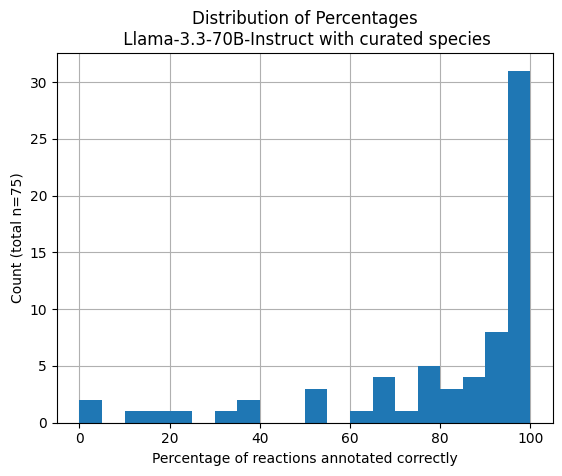

In [18]:
ax = plt.gca()
ax.set_axisbelow(True)        # grid behind bars
plt.grid(True)           # y-axis gridlines only

plt.hist(pct_found["pct_found"], bins=20)
plt.xlabel("Percentage of reactions annotated correctly")
plt.ylabel("Count (total n=75)")
plt.title(f"Distribution of Percentages\n {llm_model} with curated species")

In [19]:
print(f"{len(pct_found[(pct_found['pct_found']<80)])} out of 75 models had an annotation accuracy < 80%")

22 out of 75 models had an annotation accuracy < 80%


In [20]:
print(f"{len(pct_found[(pct_found['pct_found']<80)])} out of 75 models had an annotation accuracy < 80%")
print(f"about {round(len(pct_found[(pct_found['pct_found']<80)])*100/75,2)}%")
print()
print(f"{len(pct_found[(pct_found['pct_found']>=80)])} out of 75 models had an annotation accuracy < 80%")
print(f"about {round(len(pct_found[(pct_found['pct_found']>=80)])*100/75,2)}%")

22 out of 75 models had an annotation accuracy < 80%
about 29.33%

46 out of 75 models had an annotation accuracy < 80%
about 61.33%


In [21]:
recall = summary_df['found'].mean()
print(f"Recall: {round(recall,2)}")

Recall: 0.71


## Llama-4-Maverick-17B-128E-Instruct-FP8

### Curated species

In [22]:
llm_model = "Llama-4-Maverick-17B-128E-Instruct-FP8"
folder = "reaction_evaluation_results/curated_species/Llama-4-Maverick-17B-128E-Instruct-FP8-20260503_020614"

In [23]:
# with curated species annotations
summary_df = pd.read_csv(f'./{folder}/per_reaction_results.csv')

# Annotation coverage: % of reactions that receive ≥1 candidate
print("Percentage of reactions that received at least one candidate: ", round(len(summary_df[summary_df['num_candidates']>0])/len(summary_df)*100,1), "%")
# top-1 accuracy:
print("Ground truth annotation within top 1: ", round(len(summary_df[summary_df['top1']==True])/len(summary_df)*100,1), "%")
# top-3 accuracy:
print("Ground truth annotation within top 3: ", round(len(summary_df[summary_df['top3']==True])/len(summary_df)*100,1), "%")
# top-5 accuracy:
print("Ground truth annotation within top 5: ", round(len(summary_df[summary_df['top5']==True])/len(summary_df)*100,1), "%")


Percentage of reactions that received at least one candidate:  74.3 %
Ground truth annotation within top 1:  69.2 %
Ground truth annotation within top 3:  70.0 %
Ground truth annotation within top 5:  70.0 %


#### Failure reasons

In [24]:
# Failure reasons
failure_reasons = summary_df[summary_df["failure_reason"].notna()]
failure_reasons["failure_reason"].value_counts()

failure_reason
no_candidates    1492
SSX                10
Name: count, dtype: int64

In [25]:
failure_reasons = summary_df[summary_df["failure_reason"].notna()]

results = []

for _, row in failure_reasons.iterrows():
    if row["failure_reason"] != "no_candidates":
        continue

    model_id = row["model_id"]
    reaction_id = row["reaction_id"]
    gt = row["ground_truth_kegg"]  # e.g. "R01845"
    gt_formatted = f"KEGG:{gt}"

    file_path = os.path.join(folder, "_work", f"{model_id}.xml_recommendations.csv")

    if not os.path.exists(file_path):
        label = "file not found"
    else:
        rec_df = pd.read_csv(file_path)

        sub = rec_df[rec_df["id"] == reaction_id]

        if sub.empty:
            label = "reaction not found in recommendations"
        else:
            if sub["annotation"].astype(str).str.contains(gt_formatted).any():
                label = "LLM did not recognize correct annotation"
            else:
                label = "no correct candidates were generated"

    results.append({
        "model_id": model_id,
        "reaction_id": reaction_id,
        "ground_truth_kegg": gt,
        "label": label
    })

output_df = pd.DataFrame(results)
output_df.to_csv(f"./{folder}/failure_reasons.csv", index=False)

#### Complexity analysis

In [26]:
result = run_complexity_analysis(f"./tests/{folder}/per_reaction_results.csv") # take 64min
result.per_reaction.to_csv(f'./{folder}/complexity_list.csv', index=False)
result.summary

Wrote C:\Users\user\Documents\research\AAAIM\tests\reaction_evaluation_results\curated_species\Llama-4-Maverick-17B-128E-Instruct-FP8-20260503_020614\per_reaction_with_complexity.csv
Wrote C:\Users\user\Documents\research\AAAIM\tests\reaction_evaluation_results\curated_species\Llama-4-Maverick-17B-128E-Instruct-FP8-20260503_020614\complexity_impact_summary.csv
complexity_bin  n_reactions  coverage  top1  top3  top5  mean_candidates
             1           17     0.647 0.647 0.647 0.647            0.647
             2          570     0.721 0.696 0.718 0.718            1.086
             3          717     0.767 0.748 0.767 0.767            0.978
             4         1961     0.711 0.701 0.711 0.711            0.876
            5+         2573     0.670 0.669 0.670 0.670            0.805


,complexity_bin,n_reactions,coverage,top1,top3,top5,mean_candidates
0,1,17,0.647,0.647,0.647,0.647,0.647
1,2,570,0.721,0.696,0.718,0.718,1.086
2,3,717,0.767,0.748,0.767,0.767,0.978
3,4,1961,0.711,0.701,0.711,0.711,0.876
4,5+,2573,0.670,0.669,0.670,0.670,0.805


In [27]:
pct_found = (
    summary_df
    .sort_values("model_id")
    .groupby("model_id")["found"]
    .mean()
    .mul(100)
    .reset_index(name="pct_found")
).round(1)

df_llm4 = pct_found

avg_annotated_correctly = round(pct_found['pct_found'].mean(), 1)
print(f"On average, {avg_annotated_correctly}% of reactions in each model were annotated correctly.")


On average, 77.1% of reactions in each model were annotated correctly.


Which models did AAAIM fail at annotating?

In [28]:
pct_found[pct_found['pct_found']==0]

,model_id,pct_found
22,BIOMD0000000108,0.0
25,BIOMD0000000137,0.0
65,BIOMD0000000691,0.0


Make a histogram of successfully annotated models

Text(0.5, 1.0, 'Distribution of Percentages\n Llama-4-Maverick-17B-128E-Instruct-FP8 with curated species')

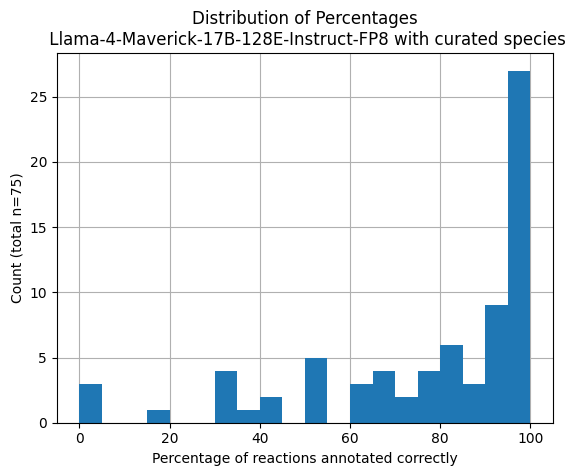

In [29]:
ax = plt.gca()
ax.set_axisbelow(True)        # grid behind bars
plt.grid(True)           # y-axis gridlines only

plt.hist(pct_found["pct_found"], bins=20)
plt.xlabel("Percentage of reactions annotated correctly")
plt.ylabel("Count (total n=75)")
plt.title(f"Distribution of Percentages\n {llm_model} with curated species")

In [30]:
print(f"{len(pct_found[(pct_found['pct_found']<80)])} out of 75 models had an annotation accuracy < 80%")
print(f"about {round(len(pct_found[(pct_found['pct_found']<80)])*100/75,2)}%")
print()
print(f"{len(pct_found[(pct_found['pct_found']>=80)])} out of 75 models had an annotation accuracy < 80%")
print(f"about {round(len(pct_found[(pct_found['pct_found']>=80)])*100/75,2)}%")

29 out of 75 models had an annotation accuracy < 80%
about 38.67%

45 out of 75 models had an annotation accuracy < 80%
about 60.0%


In [31]:
recall = summary_df['found'].mean()
print(f"Recall: {round(recall,2)}")

Recall: 0.7


### Curated species, no BRITE

In [ ]:
llm_model = "Llama-3.3-70B-Instruct"
folder = "reaction_evaluation_results/curated_species/Llama-4-Maverick-17B-128E-Instruct-FP8-20260507_214934-no-brite"

In [ ]:
# with curated species annotations
summary_df = pd.read_csv(f'./{folder}/per_reaction_results.csv')

# Annotation coverage: % of reactions that receive ≥1 candidate
print("Percentage of reactions that received at least one candidate: ", round(len(summary_df[summary_df['num_candidates']>0])/len(summary_df)*100,1), "%")
# top-1 accuracy:
print("Ground truth annotation within top 1: ", round(len(summary_df[summary_df['top1']==True])/len(summary_df)*100,1), "%")
# top-3 accuracy:
print("Ground truth annotation within top 3: ", round(len(summary_df[summary_df['top3']==True])/len(summary_df)*100,1), "%")
# top-5 accuracy:
print("Ground truth annotation within top 5: ", round(len(summary_df[summary_df['top5']==True])/len(summary_df)*100,1), "%")


### Curated species, no cofactors

In [ ]:
llm_model = "Llama-3.3-70B-Instruct"
folder = "reaction_evaluation_results/curated_species/Llama-4-Maverick-17B-128E-Instruct-FP8-20260506_014246-no-cofactors"

In [ ]:
# with curated species annotations
summary_df = pd.read_csv(f'./{folder}/per_reaction_results.csv')

# Annotation coverage: % of reactions that receive ≥1 candidate
print("Percentage of reactions that received at least one candidate: ", round(len(summary_df[summary_df['num_candidates']>0])/len(summary_df)*100,1), "%")
# top-1 accuracy:
print("Ground truth annotation within top 1: ", round(len(summary_df[summary_df['top1']==True])/len(summary_df)*100,1), "%")
# top-3 accuracy:
print("Ground truth annotation within top 3: ", round(len(summary_df[summary_df['top3']==True])/len(summary_df)*100,1), "%")
# top-5 accuracy:
print("Ground truth annotation within top 5: ", round(len(summary_df[summary_df['top5']==True])/len(summary_df)*100,1), "%")


### AAAIM species

In [32]:
llm_model = "Llama-4-Maverick-17B-128E-Instruct-FP8"
folder = "reaction_evaluation_results/aaaim_species/Llama-4-Maverick-17B-128E-Instruct-FP8-20260506_013857"

In [33]:
# with curated species annotations
summary_df = pd.read_csv(f'./{folder}/per_reaction_results.csv')

# Annotation coverage: % of reactions that receive ≥1 candidate
print("Percentage of reactions that received at least one candidate: ", round(len(summary_df[summary_df['num_candidates']>0])/len(summary_df)*100,1), "%")
# top-1 accuracy:
print("Ground truth annotation within top 1: ", round(len(summary_df[summary_df['top1']==True])/len(summary_df)*100,1), "%")
# top-3 accuracy:
print("Ground truth annotation within top 3: ", round(len(summary_df[summary_df['top3']==True])/len(summary_df)*100,1), "%")
# top-5 accuracy:
print("Ground truth annotation within top 5: ", round(len(summary_df[summary_df['top5']==True])/len(summary_df)*100,1), "%")


Percentage of reactions that received at least one candidate:  80.3 %
Ground truth annotation within top 1:  78.3 %
Ground truth annotation within top 3:  79.3 %
Ground truth annotation within top 5:  79.3 %


#### Failure reasons

In [34]:
# Failure reasons
failure_reasons = summary_df[summary_df["failure_reason"].notna()]
failure_reasons["failure_reason"].value_counts()

failure_reason
no_candidates    713
SSX               10
Name: count, dtype: int64

In [35]:
failure_reasons = summary_df[summary_df["failure_reason"].notna()]

results = []

for _, row in failure_reasons.iterrows():
    if row["failure_reason"] != "no_candidates":
        continue

    model_id = row["model_id"]
    reaction_id = row["reaction_id"]
    gt = row["ground_truth_kegg"]  # e.g. "R01845"
    gt_formatted = f"KEGG:{gt}"

    file_path = os.path.join(folder, "_work", f"{model_id}.xml_recommendations.csv")

    if not os.path.exists(file_path):
        label = "file not found"
    else:
        rec_df = pd.read_csv(file_path)

        sub = rec_df[rec_df["id"] == reaction_id]

        if sub.empty:
            label = "reaction not found in recommendations"
        else:
            if sub["annotation"].astype(str).str.contains(gt_formatted).any():
                label = "LLM did not recognize correct annotation"
            else:
                label = "no correct candidates were generated"

    results.append({
        "model_id": model_id,
        "reaction_id": reaction_id,
        "ground_truth_kegg": gt,
        "label": label
    })

output_df = pd.DataFrame(results)
output_df.to_csv(f"./{folder}/failure_reasons.csv", index=False)

#### Complexity analysis

In [36]:
result = run_complexity_analysis(f"./tests/{folder}/per_reaction_results.csv") # take 64min
result.per_reaction.to_csv(f'./{folder}/complexity_list.csv', index=False)
result.summary

Wrote C:\Users\user\Documents\research\AAAIM\tests\reaction_evaluation_results\aaaim_species\Llama-4-Maverick-17B-128E-Instruct-FP8-20260506_013857\per_reaction_with_complexity.csv
Wrote C:\Users\user\Documents\research\AAAIM\tests\reaction_evaluation_results\aaaim_species\Llama-4-Maverick-17B-128E-Instruct-FP8-20260506_013857\complexity_impact_summary.csv
complexity_bin  n_reactions  coverage  top1  top3  top5  mean_candidates
             1           17     0.647 0.647 0.647 0.647            0.647
             2          439     0.879 0.868 0.877 0.877            1.130
             3          501     0.846 0.820 0.846 0.846            0.986
             4         1244     0.803 0.788 0.803 0.803            0.850
            5+         1476     0.743 0.742 0.743 0.743            0.752


,complexity_bin,n_reactions,coverage,top1,top3,top5,mean_candidates
0,1,17,0.647,0.647,0.647,0.647,0.647
1,2,439,0.879,0.868,0.877,0.877,1.130
2,3,501,0.846,0.820,0.846,0.846,0.986
3,4,1244,0.803,0.788,0.803,0.803,0.850
4,5+,1476,0.743,0.742,0.743,0.743,0.752


In [37]:
pct_found = (
    summary_df
    .sort_values("model_id")
    .groupby("model_id")["found"]
    .mean()
    .mul(100)
    .reset_index(name="pct_found")
).round(1)
pct_found

avg_annotated_correctly = round(pct_found['pct_found'].mean(), 1)
print(f"On average, {avg_annotated_correctly}% of reactions in each model were annotated correctly.")


On average, 79.3% of reactions in each model were annotated correctly.


Which models did AAAIM fail at annotating?

In [38]:
pct_found[pct_found['pct_found']==0]

,model_id,pct_found
20,BIOMD0000000108,0.0
23,BIOMD0000000137,0.0
62,BIOMD0000000691,0.0


Make a histogram of successfully annotated models

Text(0.5, 1.0, 'Distribution of Percentages\n Llama-4-Maverick-17B-128E-Instruct-FP8 with curated species')

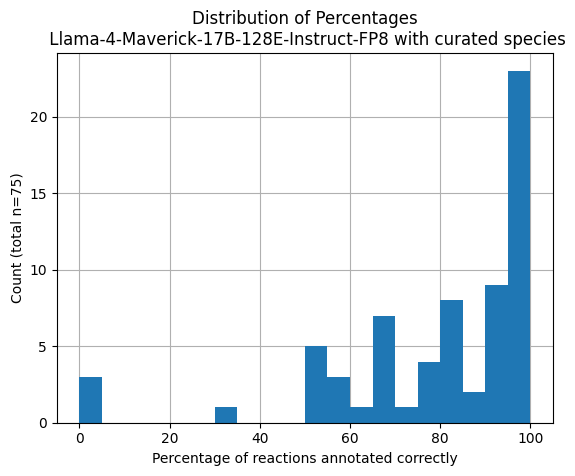

In [39]:
ax = plt.gca()
ax.set_axisbelow(True)        # grid behind bars
plt.grid(True)           # y-axis gridlines only

plt.hist(pct_found["pct_found"], bins=20)
plt.xlabel("Percentage of reactions annotated correctly")
plt.ylabel("Count (total n=75)")
plt.title(f"Distribution of Percentages\n {llm_model} with curated species")

In [40]:
print(f"{len(pct_found[(pct_found['pct_found']<80)])} out of 75 models had an annotation accuracy < 80%")
print(f"about {round(len(pct_found[(pct_found['pct_found']<80)])*100/75,2)}%")
print()
print(f"{len(pct_found[(pct_found['pct_found']>=80)])} out of 75 models had an annotation accuracy < 80%")
print(f"about {round(len(pct_found[(pct_found['pct_found']>=80)])*100/75,2)}%")

25 out of 75 models had an annotation accuracy < 80%
about 33.33%

42 out of 75 models had an annotation accuracy < 80%
about 56.0%


In [41]:
recall = summary_df['found'].mean()
print(f"Recall: {round(recall,2)}")

Recall: 0.79


## gpt-5-mini

### Curated species

In [42]:
llm_model = "gpt-5-mini"
folder = "reaction_evaluation_results/curated_species/gpt-5-mini-2025-08-07-20260503_023732"

In [43]:
# with curated species annotations
summary_df = pd.read_csv(f'./{folder}/per_reaction_results.csv')

# Annotation coverage: % of reactions that receive ≥1 candidate
print("Percentage of reactions that received at least one candidate: ", round(len(summary_df[summary_df['num_candidates']>0])/len(summary_df)*100,1), "%")
# top-1 accuracy:
print("Ground truth annotation within top 1: ", round(len(summary_df[summary_df['top1']==True])/len(summary_df)*100,1), "%")
# top-3 accuracy:
print("Ground truth annotation within top 3: ", round(len(summary_df[summary_df['top3']==True])/len(summary_df)*100,1), "%")
# top-5 accuracy:
print("Ground truth annotation within top 5: ", round(len(summary_df[summary_df['top5']==True])/len(summary_df)*100,1), "%")


Percentage of reactions that received at least one candidate:  83.9 %
Ground truth annotation within top 1:  78.8 %
Ground truth annotation within top 3:  79.5 %
Ground truth annotation within top 5:  79.5 %


#### Failure reasons

In [44]:
# Failure reasons
failure_reasons = summary_df[summary_df["failure_reason"].notna()]
failure_reasons["failure_reason"].value_counts()

failure_reason
no_candidates    940
SSX                2
Name: count, dtype: int64

In [45]:
failure_reasons = summary_df[summary_df["failure_reason"].notna()]

results = []

for _, row in failure_reasons.iterrows():
    if row["failure_reason"] != "no_candidates":
        continue

    model_id = row["model_id"]
    reaction_id = row["reaction_id"]
    gt = row["ground_truth_kegg"]  # e.g. "R01845"
    gt_formatted = f"KEGG:{gt}"

    file_path = os.path.join(folder, "_work", f"{model_id}.xml_recommendations.csv")

    if not os.path.exists(file_path):
        label = "file not found"
    else:
        rec_df = pd.read_csv(file_path)

        sub = rec_df[rec_df["id"] == reaction_id]

        if sub.empty:
            label = "reaction not found in recommendations"
        else:
            if sub["annotation"].astype(str).str.contains(gt_formatted).any():
                label = "LLM did not recognize correct annotation"
            else:
                label = "no correct candidates were generated"

    results.append({
        "model_id": model_id,
        "reaction_id": reaction_id,
        "ground_truth_kegg": gt,
        "label": label
    })

output_df = pd.DataFrame(results)
output_df.to_csv(f"./{folder}/failure_reasons.csv", index=False)

#### Complexity analysis

In [46]:
result = run_complexity_analysis(f"./tests/{folder}/per_reaction_results.csv") # take 64min
result.per_reaction.to_csv(f'./{folder}/complexity_list.csv', index=False)
result.summary

Wrote C:\Users\user\Documents\research\AAAIM\tests\reaction_evaluation_results\curated_species\gpt-5-mini-2025-08-07-20260503_023732\per_reaction_with_complexity.csv
Wrote C:\Users\user\Documents\research\AAAIM\tests\reaction_evaluation_results\curated_species\gpt-5-mini-2025-08-07-20260503_023732\complexity_impact_summary.csv
complexity_bin  n_reactions  coverage  top1  top3  top5  mean_candidates
             1           17     0.882 0.882 0.882 0.882            0.882
             2          570     0.807 0.779 0.800 0.804            1.068
             3          717     0.845 0.827 0.844 0.845            0.964
             4         1961     0.796 0.790 0.795 0.796            0.917
            5+         2573     0.779 0.777 0.779 0.779            0.846


,complexity_bin,n_reactions,coverage,top1,top3,top5,mean_candidates
0,1,17,0.882,0.882,0.882,0.882,0.882
1,2,570,0.807,0.779,0.800,0.804,1.068
2,3,717,0.845,0.827,0.844,0.845,0.964
3,4,1961,0.796,0.790,0.795,0.796,0.917
4,5+,2573,0.779,0.777,0.779,0.779,0.846


In [47]:
pct_found = (
    summary_df
    .sort_values("model_id")
    .groupby("model_id")["found"]
    .mean()
    .mul(100)
    .reset_index(name="pct_found")
).round(1)

df_gpt5 = pct_found

avg_annotated_correctly = round(pct_found['pct_found'].mean(), 1)
print(f"On average, {avg_annotated_correctly}% of reactions in each model were annotated correctly.")


On average, 84.7% of reactions in each model were annotated correctly.


Which models did AAAIM fail at annotating?

In [48]:
pct_found[pct_found['pct_found']==0]

,model_id,pct_found
22,BIOMD0000000108,0.0


Make a histogram of successfully annotated models

Text(0.5, 1.0, 'Distribution of Percentages\n gpt-5-mini with curated species')

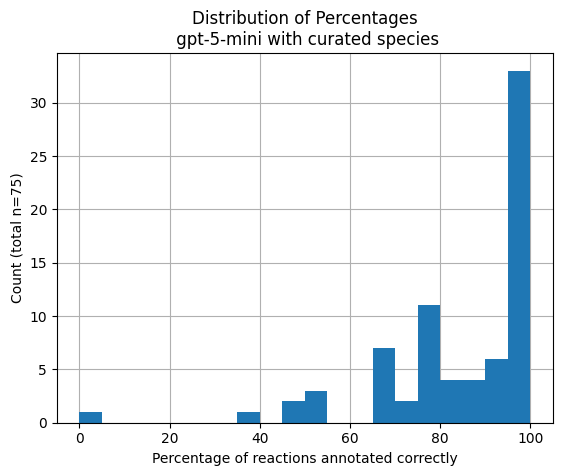

In [49]:
ax = plt.gca()
ax.set_axisbelow(True)        # grid behind bars
plt.grid(True)           # y-axis gridlines only

plt.hist(pct_found["pct_found"], bins=20)
plt.xlabel("Percentage of reactions annotated correctly")
plt.ylabel("Count (total n=75)")
plt.title(f"Distribution of Percentages\n {llm_model} with curated species")

In [50]:
print(f"{len(pct_found[(pct_found['pct_found']<80)])} out of 75 models had an annotation accuracy < 80%")
print(f"about {round(len(pct_found[(pct_found['pct_found']<80)])*100/75,2)}%")
print()
print(f"{len(pct_found[(pct_found['pct_found']>=80)])} out of 75 models had an annotation accuracy < 80%")
print(f"about {round(len(pct_found[(pct_found['pct_found']>=80)])*100/75,2)}%")

27 out of 75 models had an annotation accuracy < 80%
about 36.0%

47 out of 75 models had an annotation accuracy < 80%
about 62.67%


### AAAIM species

In [53]:
llm_model = "gpt-5-mini"
folder = "reaction_evaluation_results/aaaim_species/gpt-5-mini-2025-08-07-20260506_014810"

In [54]:
# with curated species annotations
summary_df = pd.read_csv(f'./{folder}/per_reaction_results.csv')

# Annotation coverage: % of reactions that receive ≥1 candidate
print("Percentage of reactions that received at least one candidate: ", round(len(summary_df[summary_df['num_candidates']>0])/len(summary_df)*100,1), "%")
# top-1 accuracy:
print("Ground truth annotation within top 1: ", round(len(summary_df[summary_df['top1']==True])/len(summary_df)*100,1), "%")
# top-3 accuracy:
print("Ground truth annotation within top 3: ", round(len(summary_df[summary_df['top3']==True])/len(summary_df)*100,1), "%")
# top-5 accuracy:
print("Ground truth annotation within top 5: ", round(len(summary_df[summary_df['top5']==True])/len(summary_df)*100,1), "%")


Percentage of reactions that received at least one candidate:  96.2 %
Ground truth annotation within top 1:  94.6 %
Ground truth annotation within top 3:  95.3 %
Ground truth annotation within top 5:  95.3 %


#### Failure reasons

In [55]:
# Failure reasons
failure_reasons = summary_df[summary_df["failure_reason"].notna()]
failure_reasons["failure_reason"].value_counts()

failure_reason
no_candidates    164
SSX                3
Name: count, dtype: int64

In [56]:
failure_reasons = summary_df[summary_df["failure_reason"].notna()]

results = []

for _, row in failure_reasons.iterrows():
    if row["failure_reason"] != "no_candidates":
        continue

    model_id = row["model_id"]
    reaction_id = row["reaction_id"]
    gt = row["ground_truth_kegg"]  # e.g. "R01845"
    gt_formatted = f"KEGG:{gt}"

    file_path = os.path.join(folder, "_work", f"{model_id}.xml_recommendations.csv")

    if not os.path.exists(file_path):
        label = "file not found"
    else:
        rec_df = pd.read_csv(file_path)

        sub = rec_df[rec_df["id"] == reaction_id]

        if sub.empty:
            label = "reaction not found in recommendations"
        else:
            if sub["annotation"].astype(str).str.contains(gt_formatted).any():
                label = "LLM did not recognize correct annotation"
            else:
                label = "no correct candidates were generated"

    results.append({
        "model_id": model_id,
        "reaction_id": reaction_id,
        "ground_truth_kegg": gt,
        "label": label
    })

output_df = pd.DataFrame(results)
output_df.to_csv(f"./{folder}/failure_reasons.csv", index=False)

#### Complexity analysis

In [57]:
result = run_complexity_analysis(f"./tests/{folder}/per_reaction_results.csv") # take 64min
result.per_reaction.to_csv(f'./{folder}/complexity_list.csv', index=False)
result.summary

Wrote C:\Users\user\Documents\research\AAAIM\tests\reaction_evaluation_results\aaaim_species\gpt-5-mini-2025-08-07-20260506_014810\per_reaction_with_complexity.csv
Wrote C:\Users\user\Documents\research\AAAIM\tests\reaction_evaluation_results\aaaim_species\gpt-5-mini-2025-08-07-20260506_014810\complexity_impact_summary.csv
complexity_bin  n_reactions  coverage  top1  top3  top5  mean_candidates
             1           17     0.824 0.824 0.824 0.824            0.824
             2          473     0.911 0.892 0.907 0.907            1.082
             3          582     0.942 0.921 0.940 0.940            1.050
             4         1452     0.957 0.949 0.957 0.957            1.003
            5+         1855     0.967 0.965 0.967 0.967            0.975


,complexity_bin,n_reactions,coverage,top1,top3,top5,mean_candidates
0,1,17,0.824,0.824,0.824,0.824,0.824
1,2,473,0.911,0.892,0.907,0.907,1.082
2,3,582,0.942,0.921,0.940,0.940,1.050
3,4,1452,0.957,0.949,0.957,0.957,1.003
4,5+,1855,0.967,0.965,0.967,0.967,0.975


In [58]:
pct_found = (
    summary_df
    .sort_values("model_id")
    .groupby("model_id")["found"]
    .mean()
    .mul(100)
    .reset_index(name="pct_found")
).round(1)
pct_found

avg_annotated_correctly = round(pct_found['pct_found'].mean(), 1)
print(f"On average, {avg_annotated_correctly}% of reactions in each model were annotated correctly.")


On average, 87.6% of reactions in each model were annotated correctly.


Which models did AAAIM fail at annotating?

In [59]:
pct_found[pct_found['pct_found']==0]

,model_id,pct_found
20,BIOMD0000000108,0.0
23,BIOMD0000000137,0.0


Make a histogram of successfully annotated models

Text(0.5, 1.0, 'Distribution of Percentages\n gpt-5-mini with curated species')

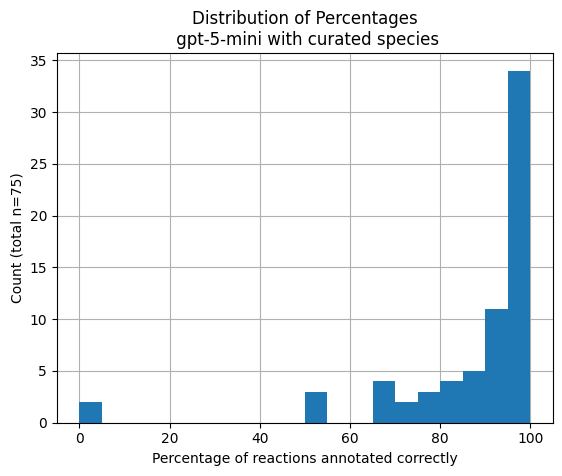

In [60]:
ax = plt.gca()
ax.set_axisbelow(True)        # grid behind bars
plt.grid(True)           # y-axis gridlines only

plt.hist(pct_found["pct_found"], bins=20)
plt.xlabel("Percentage of reactions annotated correctly")
plt.ylabel("Count (total n=75)")
plt.title(f"Distribution of Percentages\n {llm_model} with curated species")

In [61]:
print(f"{len(pct_found[(pct_found['pct_found']<80)])} out of 75 models had an annotation accuracy < 80%")
print(f"about {round(len(pct_found[(pct_found['pct_found']<80)])*100/75,2)}%")
print()
print(f"{len(pct_found[(pct_found['pct_found']>=80)])} out of 75 models had an annotation accuracy < 80%")
print(f"about {round(len(pct_found[(pct_found['pct_found']>=80)])*100/75,2)}%")

14 out of 75 models had an annotation accuracy < 80%
about 18.67%

54 out of 75 models had an annotation accuracy < 80%
about 72.0%


# Combined Statistics

In [ ]:
dfs = {
    "llm3": df_llm3,
    "llm4": df_llm4,
    "gpt5": df_gpt5
}

# set model_id as index and extract pct_found
aligned = {
    name: df.set_index("model_id")["pct_found"]
    for name, df in dfs.items()
}

# combine into one dataframe
score_comparison_df = pd.DataFrame(aligned).T
score_comparison_df.dropna(axis=1, inplace=True)
score_comparison_df.to_csv('annotation_rate_by_model.csv')
score_comparison_df

In [ ]:
# how many times did each model have the highest number in the column?
counts = score_comparison_df.eq(score_comparison_df.max(axis=0), axis=1).sum(axis=1)
counts

In [ ]:
FAILURE_CUTOFF = 50
failed_annotations_df = score_comparison_df.loc[:, (score_comparison_df <= FAILURE_CUTOFF).any(axis=0)]
failed_annotations_df

In [ ]:
# which models where all 3 LLM models scored a 50% or less?
score_comparison_df.columns[(score_comparison_df <= 50).all(axis=0)]

Looks like there's only 2 kegg reactions to annotate in BIOMD68, and one of them is consistently annotated incorrectly. 

For BIOMD 88, 108, and 691, the species and reactions are not named in meaningful ways. 
for BIOMD 725, the species are named in meaningful ways, but the reactions are not. 

Which reactions in BIOMD 725 are not being annotated correctly? 

In [ ]:
llm_model_id = "llm4"
# mean score per model_id
col_means = score_comparison_df.loc[llm_model_id] #score_comparison_df.mean(axis=0)

# attach scores
meaningful_df = pd.read_csv("meaningful.csv")
meaningful_df = meaningful_df.replace("mixed", "y")
df = meaningful_df.set_index("model_id").join(col_means.rename("score"))

# pivot into 2x2 table
result = df.pivot_table(
    index="species",     # rows
    columns="reactions", # columns
    values="score",
    aggfunc="mean"
)

# optional: rename for clarity
result.index = result.index.map({
    "y": "Species meaningful",
    "n": "Species not meaningful"
})
result.columns = result.columns.map({
    "y": "Reaction meaningful",
    "n": "Reaction not meaningful"
})

print(f"Results for {llm_model_id}")
result

In [ ]:
# how does length of reactions and species affect the annotation accuracy?
folder = "reaction_evaluation_results/curated_species/gpt-5-mini-2025-08-07-20260503_023732"
model_times_df = pd.read_csv(f"./{folder}/per_model_timing.csv") # take 64min

In [ ]:
llm_model_id = "llm4"

x = model_times_df[['model_id', 'num_evaluated_reactions']]
y = score_comparison_df.T

merged_df = pd.merge(x, y, on="model_id")

plt.scatter(merged_df['num_evaluated_reactions'], merged_df['llm3'], alpha=0.8, label="Llama-3")
plt.scatter(merged_df['num_evaluated_reactions'], merged_df['llm4'], alpha=0.8, label="Llama-4")
plt.scatter(merged_df['num_evaluated_reactions'], merged_df['gpt5'], alpha=0.8, label="gpt-5-mini")
plt.legend()#bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.xscale("log")
plt.grid()
plt.gca().set_axisbelow(True)
plt.grid(True)
# plt.xlim((0,100))
plt.ylabel("Annotation accuracy (%)")
plt.xlabel("Number of reactions evaluated")
plt.title("Effect of reaction length on annotation accuracy")

## Reasons for failure

In [ ]:
failure percentage by reason
Models 